In [46]:
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [47]:
class PermeabilityDataset(Dataset):
    def __init__(self, image_dir, csv_path):
        """
        Dataset class for permeability prediction using normalized values
        """
        # Read data and validate
        self.data_df = pd.read_csv(csv_path)[['angle', 'Permeability_X', 'image_name']]
        self.image_dir = image_dir
        
        # Check for NaN or invalid values in CSV
        if self.data_df[['angle', 'Permeability_X', 'image_name']].isna().any().any():
            raise ValueError("NaN values found in CSV data")
        # if not self.data_df['aug_perm'].between(0, 1).all():
        #     print("Warning: aug_perm values not in [0, 1], normalizing...")
        #     perm_min = self.data_df['aug_perm'].min()
        #     perm_max = self.data_df['aug_perm'].max()
        #     self.data_df['aug_perm'] = (self.data_df['aug_perm'] - perm_min) / (perm_max - perm_min)
        
        # Group by image_name to get 0-degree normalized permeability
        self.image_data = {}
        for name, group in self.data_df.groupby('image_name'):
            # Ensure 0-degree data exists
            zero_deg = group[group['angle'] == 0]
            if len(zero_deg) == 0:
                print(f"Warning: No 0-degree data for image {name}")
                continue
            zero_deg_perm = zero_deg['Permeability_X'].iloc[0]
            other_angles = group[group['angle'] != 0]
            self.image_data[name] = {
                'zero_perm': zero_deg_perm,
                'other_angles': other_angles
            }
        
        # Create samples list
        self.samples = []
        for img_name, data in self.image_data.items():
            for _, row in data['other_angles'].iterrows():
                self.samples.append({
                    'image_name': img_name,
                    'zero_perm': data['zero_perm'],
                    'target_angle': row['angle'],
                    'target_perm': row['Permeability_X']
                })
        
        # Image preprocessing
        self.transform = transforms.Compose([
            transforms.ToTensor(),  # Converts to [0, 1] for grayscale
        ])
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Load and transform image
        image_path = os.path.join(self.image_dir, f"{int(sample['image_name'])}.tiff")
        try:
            image = Image.open(image_path)
            # Convert to grayscale if necessary
            if image.mode != 'L':
                image = image.convert('L')  # Grayscale
        except Exception as e:
            raise ValueError(f"Error loading image {image_path}: {str(e)}")
            
        image = self.transform(image)
        
        # Validate image data
        if torch.isnan(image).any() or torch.isinf(image).any():
            raise ValueError(f"Invalid image data for {image_path}")
        
        # Normalize angle to [0, 1]
        target_angle_norm = sample['target_angle'] / 180.0
        
        # Validate sample data
        for key, value in [('zero_perm', sample['zero_perm']), 
                          ('target_angle', target_angle_norm), 
                          ('target_perm', sample['target_perm'])]:
            if np.isnan(value) or np.isinf(value):
                raise ValueError(f"Invalid {key} in sample {sample}")
        
        return {
            'image': image,
            'zero_perm': torch.tensor(sample['zero_perm'], dtype=torch.float32),
            'target_angle': torch.tensor(target_angle_norm, dtype=torch.float32),
            'target_perm': torch.tensor(sample['target_perm'], dtype=torch.float32)
        }

In [48]:
# class ReferenceDeepONet(nn.Module):
#     def __init__(self, branch_dim=32, trunk_dim=32):
#         super(ReferenceDeepONet, self).__init__()
        
#         # Branch network
#         self.branch_cnn = nn.Sequential(
#             nn.Conv2d(1, 16, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Conv2d(16, 32, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Conv2d(64, 4, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2)
            
            
#         )
        
#         # Process zero-degree permeability
#         self.zero_perm_net = nn.Sequential(
#             nn.Linear(1, 32),
#             nn.ReLU(),
#             nn.Linear(32, 2)
#         )
        
#         # Final branch network layers
#         self.branch_fc = nn.Sequential(
#             nn.Linear(1024+ 2, 128),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(128, branch_dim)
#         )
        
#         # Trunk network
#         self.trunk_net = nn.Sequential(
#             nn.Linear(2, 64),
#             nn.ReLU(),
#             nn.Linear(64, trunk_dim)
#         )
        
#         # Bias vector
#         self.bias = nn.Parameter(torch.zeros(1))
        
#     def encode_angle(self, angle):
#         return torch.stack([
#             torch.sin(2 * np.pi * angle),
#             torch.cos(2 * np.pi * angle)
#         ], dim=-1)
        
#     def forward(self, image, zero_perm, target_angle):
#         x_img = self.branch_cnn(image)
#         x_img = x_img.view(x_img.size(0), -1)
        
#         x_zero = self.zero_perm_net(zero_perm.unsqueeze(-1))
        
#         branch_input = torch.cat([x_img, x_zero], dim=1)
#         branch_output = self.branch_fc(branch_input)
        
#         trunk_output = self.trunk_net(self.encode_angle(target_angle))
        
#         output = torch.sum(branch_output * trunk_output, dim=1, keepdim=True) + self.bias
        
#         return output

In [49]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ReferenceDeepONet(nn.Module):
    def __init__(self, branch_dim=64, trunk_dim=64):  # Increased default dimensions
        super(ReferenceDeepONet, self).__init__()
        
        # Branch network (ResNet-inspired CNN)
        self.branch_cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            ResidualBlock(16, 16),
            ResidualBlock(16, 32, stride=2),
            ResidualBlock(32, 32),
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # Process zero-degree permeability
        self.zero_perm_net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )
        
        # Final branch network layers
        self.branch_fc = nn.Sequential(
            nn.Linear(64 + 2, 256),  # Increased intermediate layer size
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, branch_dim)
        )
        
        # Trunk network
        self.trunk_net = nn.Sequential(
            nn.Linear(2, 128),  # Increased intermediate layer size
            nn.ReLU(),
            nn.Linear(128, trunk_dim)
        )
        
        # Bias vector
        self.bias = nn.Parameter(torch.zeros(1))
    
    def encode_angle(self, angle):
        return torch.stack([
            torch.sin(2 * torch.pi * angle),
            torch.cos(2 * torch.pi * angle)
        ], dim=-1)
    
    def forward(self, image, zero_perm, target_angle):
        x_img = self.branch_cnn(image)
        x_img = x_img.view(x_img.size(0), -1)
        
        x_zero = self.zero_perm_net(zero_perm.unsqueeze(-1))
        
        branch_input = torch.cat([x_img, x_zero], dim=1)
        branch_output = self.branch_fc(branch_input)
        
        trunk_output = self.trunk_net(self.encode_angle(target_angle))
        
        output = torch.sum(branch_output * trunk_output, dim=1, keepdim=True) + self.bias
        return output

In [50]:

def train_model(model, train_loader, val_loader, num_epochs=100):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nUsing device: {device}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    train_loss_history = []
    val_loss_history = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_preds = []
        train_targets = []
        for batch in train_loader:
            images = batch['image'].to(device)
            zero_perms = batch['zero_perm'].to(device)
            target_angles = batch['target_angle'].to(device)
            target_perms = batch['target_perm'].to(device)
            
            optimizer.zero_grad()
            outputs = model(images, zero_perms, target_angles)
            loss = criterion(outputs, target_perms.unsqueeze(1))
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            train_preds.append(outputs.detach().cpu().numpy())
            train_targets.append(target_perms.unsqueeze(1).detach().cpu().numpy())
        
        train_loss = train_loss / len(train_loader)
        train_loss_history.append(train_loss)
        
        # Compute Training R^2 using sklearn
        train_preds = np.concatenate(train_preds)
        train_targets = np.concatenate(train_targets)
        train_r2 = r2_score(train_targets, train_preds)
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device)
                zero_perms = batch['zero_perm'].to(device)
                target_angles = batch['target_angle'].to(device)
                target_perms = batch['target_perm'].to(device)
                
                outputs = model(images, zero_perms, target_angles)
                loss = criterion(outputs, target_perms.unsqueeze(1))
                val_loss += loss.item()
                
                val_preds.append(outputs.detach().cpu().numpy())
                val_targets.append(target_perms.unsqueeze(1).detach().cpu().numpy())
        
        val_loss = val_loss / len(val_loader)
        val_loss_history.append(val_loss)
        
        # Compute Validation R^2 using sklearn
        val_preds_np = np.concatenate(val_preds)
        val_targets_np = np.concatenate(val_targets)
        val_r2 = r2_score(val_targets_np, val_preds_np)
        
        scheduler.step(val_loss)
        
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Training Loss: {train_loss:.4f}')
        print(f'Validation Loss: {val_loss:.4f}')
        print(f'Training R^2: {train_r2:.4f}')
        print(f'Validation R^2: {val_r2:.4f}')
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_val_loss
            }, 'best_model.pth')
    
    # Plot Training and Validation MSE
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs + 1), train_loss_history, label='Training MSE', marker='o')
    plt.plot(range(1, num_epochs + 1), val_loss_history, label='Validation MSE', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title('Training and Validation MSE over Epochs')
    plt.legend()
    plt.grid(True)
    plt.savefig('mse_plot.png')
    plt.show()
    
    # Scatterplot for Validation with R^2 Annotation
    plt.figure(figsize=(8, 8))
    plt.scatter(val_targets_np, val_preds_np, alpha=0.5)
    
    # Plot y=x line for reference
    plt.plot([val_targets_np.min(), val_targets_np.max()], 
             [val_targets_np.min(), val_targets_np.max()], 
             'k--')
    
    # Annotate R^2 value on the plot
    plt.text(0.05, 0.95, f'R² = {val_r2:.4f}', transform=plt.gca().transAxes, 
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.xlabel('Actual Permeability')
    plt.ylabel('Predicted Permeability')
    plt.title('Validation Predictions vs Actual')
    plt.legend()
    plt.grid(True)
    plt.savefig('validation_scatter.png')
    plt.show()

In [51]:
def load_data(image_dir, csv_path, batch_size=128, train_split=0.85):
    dataset = PermeabilityDataset(image_dir, csv_path)
    print(f"Dataset size: {len(dataset)}")
    
    train_size = int(train_split * len(dataset))
    val_size = len(dataset) - train_size
    
    train_dataset, val_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size]
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )
    
    return train_loader, val_loader

Dataset size: 31122

Using device: cuda
GPU: NVIDIA RTX A4000
Epoch [1/100]
Training Loss: 1.7643
Validation Loss: 1.0147
Training R^2: 0.8037
Validation R^2: 0.8907
Epoch [2/100]
Training Loss: 1.2431
Validation Loss: 1.0697
Training R^2: 0.8616
Validation R^2: 0.8848
Epoch [3/100]
Training Loss: 1.1328
Validation Loss: 1.0399
Training R^2: 0.8739
Validation R^2: 0.8880
Epoch [4/100]
Training Loss: 1.0811
Validation Loss: 0.7877
Training R^2: 0.8797
Validation R^2: 0.9152
Epoch [5/100]
Training Loss: 0.9882
Validation Loss: 0.7334
Training R^2: 0.8900
Validation R^2: 0.9211
Epoch [6/100]
Training Loss: 0.9108
Validation Loss: 1.0625
Training R^2: 0.8986
Validation R^2: 0.8856
Epoch [7/100]
Training Loss: 0.8629
Validation Loss: 0.6902
Training R^2: 0.9040
Validation R^2: 0.9257
Epoch [8/100]
Training Loss: 0.8685
Validation Loss: 0.5794
Training R^2: 0.9033
Validation R^2: 0.9376
Epoch [9/100]
Training Loss: 0.8339
Validation Loss: 1.0840
Training R^2: 0.9072
Validation R^2: 0.8833
Ep

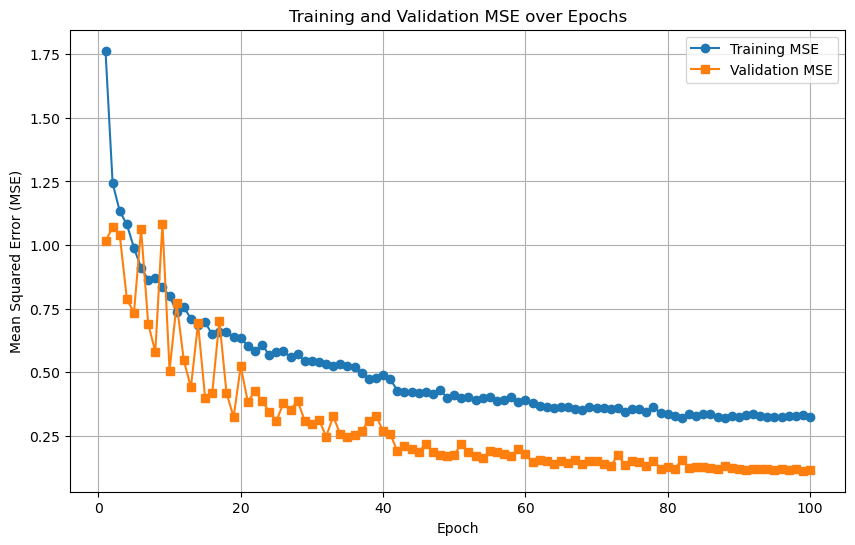

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


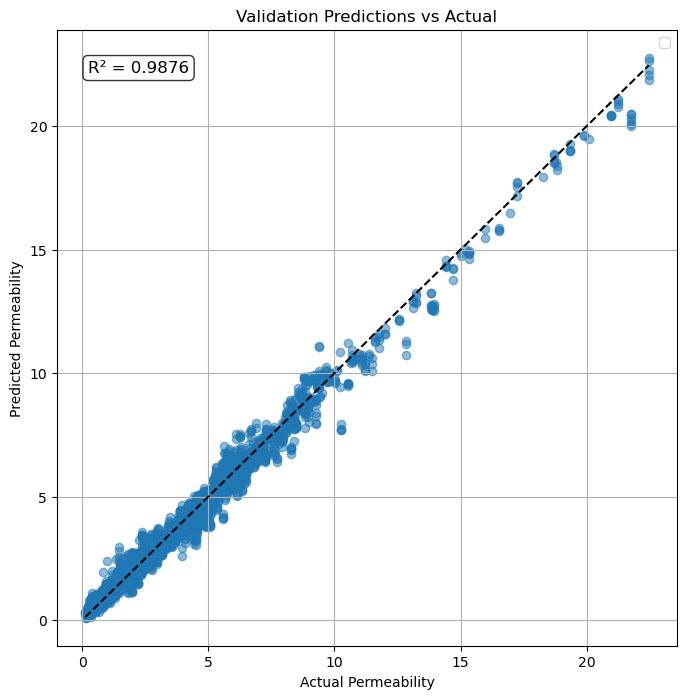

In [52]:

def main():
    image_dir = 'training'
    csv_path = 'training.csv'
    
    train_loader, val_loader = load_data(
        image_dir=image_dir,
        csv_path=csv_path,
        batch_size=32
    )
    
    model = ReferenceDeepONet()
    train_model(model, train_loader, val_loader)

if __name__ == "__main__":
    main()

In [57]:
from sklearn.metrics import r2_score

def test_model(model, test_image_dir, test_csv_path, checkpoint_path='best_model.pth', batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nTesting on device: {device}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    
    # Initialize model
    model = model.to(device)
    model.eval()
    
    # Load checkpoint
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded checkpoint from epoch {checkpoint['epoch']+1} with validation loss {checkpoint['loss']:.4f}")
    except FileNotFoundError:
        raise FileNotFoundError(f"Checkpoint file {checkpoint_path} not found")
    except Exception as e:
        raise ValueError(f"Error loading checkpoint: {str(e)}")
    
    # Load test dataset
    test_dataset = PermeabilityDataset(test_image_dir, test_csv_path)
    print(f"Test dataset size: {len(test_dataset)}")
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )
    
    # Evaluate on test set
    criterion = nn.MSELoss()
    test_loss = 0
    test_preds = []
    test_targets = []
    test_angles = []
    test_image_names = []
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            images = batch['image'].to(device)
            zero_perms = batch['zero_perm'].to(device)
            target_angles = batch['target_angle'].to(device)
            target_perms = batch['target_perm'].to(device)
            
            outputs = model(images, zero_perms, target_angles)
            loss = criterion(outputs, target_perms.unsqueeze(1))
            test_loss += loss.item()
            
            test_preds.append(outputs.detach().cpu().numpy())
            test_targets.append(target_perms.unsqueeze(1).detach().cpu().numpy())
            batch_angles = target_angles.detach().cpu().numpy() * 180.0  # Denormalize angles
            test_angles.append(batch_angles)
            
            # Compute sample indices for this batch
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(test_dataset))
            batch_indices = list(range(start_idx, end_idx))
            batch_image_names = [test_dataset.samples[i]['image_name'] for i in batch_indices]
            test_image_names.extend(batch_image_names)
            
            # Debug: Print angles to confirm non-zero
            print(f"Batch {batch_idx+1}: Angles = {batch_angles.tolist()}")
    
    test_loss = test_loss / len(test_loader)
    
    # Compute Test R^2 for entire test set
    test_preds_np = np.concatenate(test_preds)
    test_targets_np = np.concatenate(test_targets)
    test_angles_np = np.concatenate(test_angles)
    test_r2 = r2_score(test_targets_np, test_preds_np)
    
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test R^2: {test_r2:.4f}")
    
    # Scatterplot for entire test set with R^2 annotation
    plt.figure(figsize=(8, 8))
    plt.scatter(test_targets_np, test_preds_np, alpha=0.5, label='Predictions')
    
    # Plot y=x line for reference
    plt.plot([test_targets_np.min(), test_targets_np.max()], 
             [test_targets_np.min(), test_targets_np.max()], 
             'k--')
    
    # Annotate R^2 value on the plot
    plt.text(0.05, 0.85, f'R² = {test_r2:.4f}', transform=plt.gca().transAxes, 
             fontsize=16, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.xlabel('Actual Permeability',   fontsize=16)
    plt.ylabel('Predicted Permeability',fontsize=16)

    plt.title('Test Predictions vs Actual')
    plt.legend()
    plt.grid(True)
    plt.savefig('test_scatter.png')
    plt.show()
    
    # Group predictions by image_name for individual plots
    image_data = {}
    for pred, target, angle, img_name in zip(test_preds_np.flatten(), test_targets_np.flatten(), 
                                            test_angles_np, test_image_names):
        if angle == 0:
            print(f"Warning: Found 0-degree angle in predictions for image {img_name}")
            continue
        if img_name not in image_data:
            image_data[img_name] = {'angles': [], 'true_perms': [], 'pred_perms': []}
        image_data[img_name]['angles'].append(angle)
        image_data[img_name]['true_perms'].append(target)
        image_data[img_name]['pred_perms'].append(pred)
    
    # Generate individual plots for each image
    for img_name, data in image_data.items():
        angles = np.array(data['angles'])
        true_perms = np.array(data['true_perms'])
        pred_perms = np.array(data['pred_perms'])

        # Compute R^2 for this image
        img_r2 = r2_score(true_perms, pred_perms)

        # Sort by angle for better visualization
        sort_idx = np.argsort(angles)
        angles = angles[sort_idx]
        true_perms = true_perms[sort_idx]
        pred_perms = pred_perms[sort_idx]

        # Plot only points (no lines)
        plt.figure(figsize=(10, 6))
        plt.plot(angles, true_perms, 'bo', label='True Permeability', marker='o', linestyle='None')
        plt.plot(angles, pred_perms, 'rs', label='Predicted Permeability', marker='s', linestyle='None')

        plt.tick_params(axis='both', labelsize=16)
        plt.xlabel('Angle (degrees)', fontsize=16)
        plt.ylabel('Permeability', fontsize=16)
        plt.title(f'Permeability vs Angle for Image {img_name}')
        plt.legend(fontsize=16)
        plt.ylim(0, 10)
        #plt.grid(True)
        plt.savefig(f'image_{img_name}_perm_plot.png')
        plt.show()

In [58]:
def load_data(image_dir, csv_path, batch_size=32):
    dataset = PermeabilityDataset(image_dir, csv_path)
    print(f"Dataset size: {len(dataset)}")
    
    test_loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
    )
    
    return test_loader


Testing on device: cuda
GPU: NVIDIA RTX A4000
Loaded checkpoint from epoch 99 with validation loss 0.1118
Test dataset size: 36
Batch 1: Angles = [10.0, 20.0, 30.0, 40.0, 50.000003814697266, 60.0, 70.0, 80.0, 90.0, 100.00000762939453, 110.0, 120.0, 130.0, 140.0, 150.0, 160.0, 170.0, 180.0, 10.0, 20.0, 30.0, 40.0, 50.000003814697266, 60.0, 70.0, 80.0, 90.0, 100.00000762939453, 110.0, 120.0, 130.0, 140.0]
Batch 2: Angles = [150.0, 160.0, 170.0, 180.0]
Test Loss: 0.8554
Test R^2: 0.8582


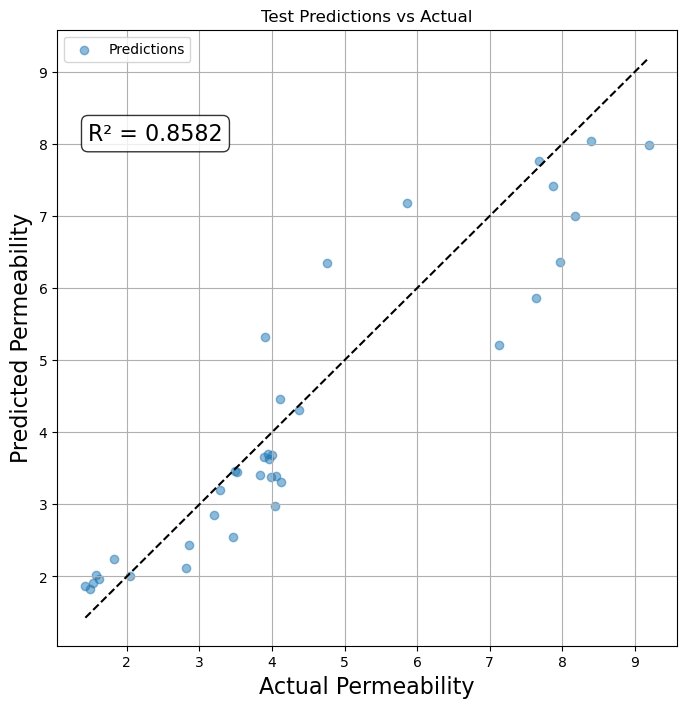

C:\Users\proy\AppData\Local\Temp\ipykernel_140204\3427412399.py:130: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(angles, true_perms, 'bo', label='True Permeability', marker='o', linestyle='None')
C:\Users\proy\AppData\Local\Temp\ipykernel_140204\3427412399.py:131: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "rs" (-> marker='s'). The keyword argument will take precedence.
  plt.plot(angles, pred_perms, 'rs', label='Predicted Permeability', marker='s', linestyle='None')


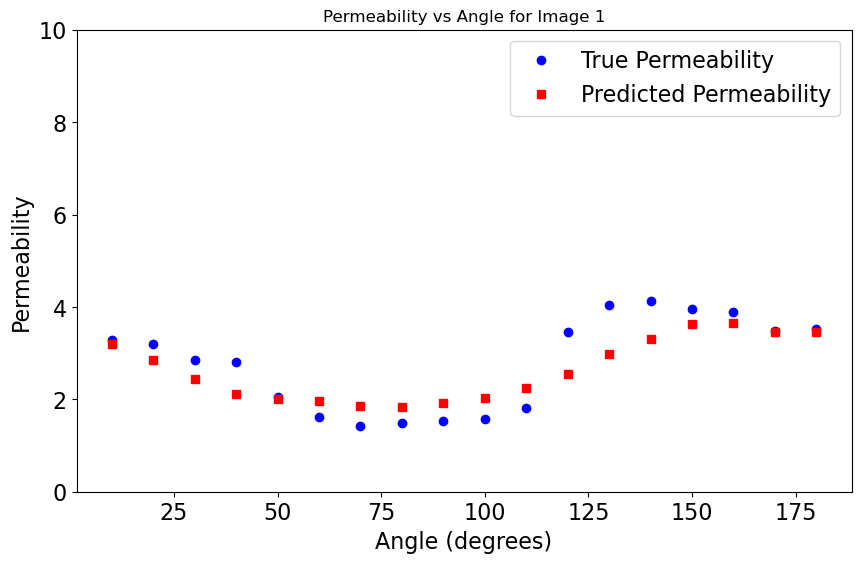

C:\Users\proy\AppData\Local\Temp\ipykernel_140204\3427412399.py:130: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(angles, true_perms, 'bo', label='True Permeability', marker='o', linestyle='None')
C:\Users\proy\AppData\Local\Temp\ipykernel_140204\3427412399.py:131: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "rs" (-> marker='s'). The keyword argument will take precedence.
  plt.plot(angles, pred_perms, 'rs', label='Predicted Permeability', marker='s', linestyle='None')


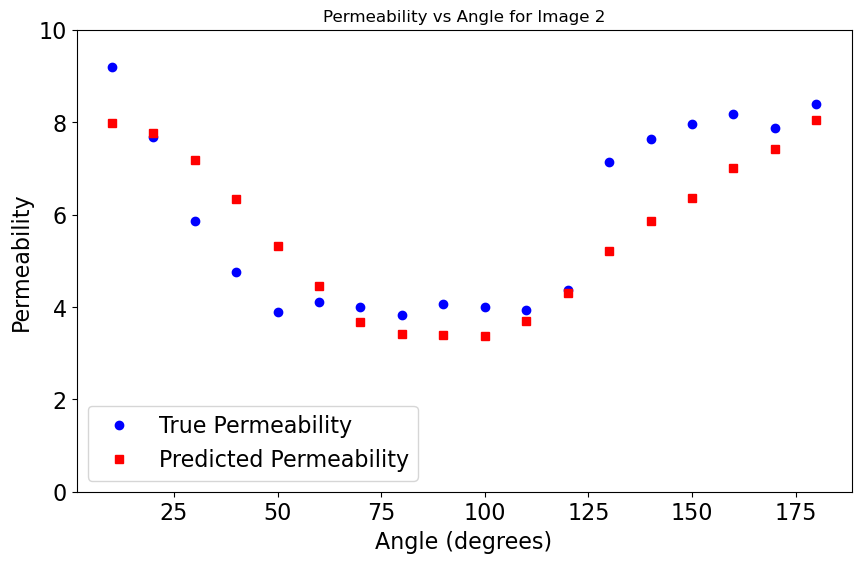

In [59]:
def main():
    test_image_dir = "test"   # Update to your test image directory
    test_csv_path = 'testing.csv'  # Update to your test CSV path
    
    # Initialize model
    model = ReferenceDeepONet()
    # Step 3: Load the checkpoint
    checkpoint_path = "best_model.pth"
    checkpoint = torch.load(checkpoint_path, map_location='cuda')

    # Step 4: Restore the model’s state dictionary
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Test the saved model
    test_model(model, test_image_dir, test_csv_path)

if __name__ == "__main__":
    main()